In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train_dataset.csv')

In [18]:
df = df[df["overall_yield"] != 0]
X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]

In [19]:
X.shape, y.shape

((113, 5), (113,))

IndexError: index 6 is out of bounds for axis 0 with size 6

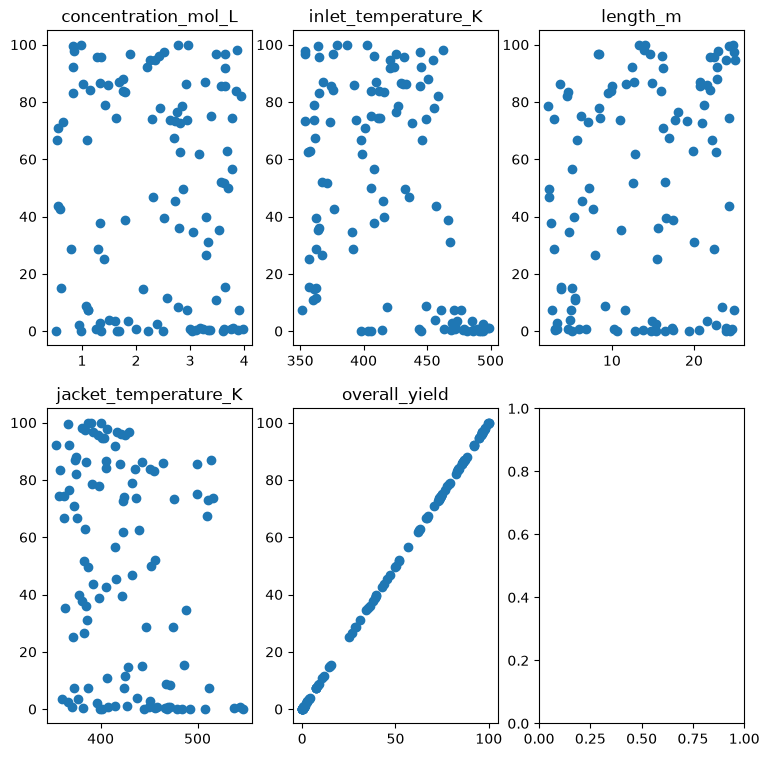

In [20]:
fig = plt.figure(figsize=(9, 9))
rows, cols = 2,3
for i in range(1, rows * cols + 1):
    # random_idx = torch.randint(0, len(train_data), size=[1]).item()
    # img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.scatter(df[df.columns[i]], df["overall_yield"])
    plt.title(df.columns[i])

In [ ]:
print(df.count())

flow_rate_L_min         113
concentration_mol_L     113
inlet_temperature_K     113
length_m                113
jacket_temperature_K    113
overall_yield           113
dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=5,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.5697220597714043
RMSE: 24.031636367308042


In [27]:
from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.5,
    depth=7,
    random_seed=42,
    verbose=0
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.5028710327567216
RMSE: 25.831126027997893


In [28]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    min_child_samples=5,
    num_leaves=15,
    verbosity=-1,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.2526430050689631
RMSE: 31.671807946046137


In [29]:
from sklearn.ensemble import ExtraTreesRegressor

ExtraTreesRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.2526430050689631
RMSE: 31.671807946046137


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, accuracy_score, f1_score

df = pd.read_csv("train_dataset.csv")

X = df.drop("overall_yield", axis=1)
y = df["overall_yield"]
y_class = (y > 0).astype(int)   # 1 = reaction occurs, 0 = no yield

X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(
    X, y, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class          # important: keep class balance in both splits
)

# --- Stage 1: classifier ---
clf = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42
)
clf.fit(X_train, yc_train)
yc_pred = clf.predict(X_test)
print("Classifier accuracy:", accuracy_score(yc_test, yc_pred))
print("Classifier F1:", f1_score(yc_test, yc_pred))

# --- Stage 2: regressor, trained ONLY on non-zero-yield rows ---
mask_train_nonzero = yc_train == 1
reg = ExtraTreesRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42
)
reg.fit(X_train[mask_train_nonzero], y_train[mask_train_nonzero])

# --- Combine: 0 where classifier says no reaction, else regressor's prediction ---
y_pred_final = pd.Series(0.0, index=X_test.index)
mask_test_reaction = yc_pred == 1
y_pred_final[mask_test_reaction] = reg.predict(X_test[mask_test_reaction])

print("Combined RMSE:", root_mean_squared_error(y_test, y_pred_final))
print("Combined R²:", r2_score(y_test, y_pred_final))

Classifier accuracy: 0.9
Classifier F1: 0.9387755102040817
Combined RMSE: 21.307832836099305
Combined R²: 0.7135961836670808


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
df = pd.read_csv("train_dataset.csv")
X = df.drop("overall_yield", axis=1).reset_index(drop=True)
y = df["overall_yield"].reset_index(drop=True)

# ---------------------------------------------------------
# Feature engineering (same as used during exploration)
# ---------------------------------------------------------
def engineer_features(X):
    X = X.copy()
    X["residence_time"] = X["length_m"] / X["flow_rate_L_min"]
    X["tau_jacketT"] = X["residence_time"] * X["jacket_temperature_K"]
    X["jacket_minus_inlet"] = X["jacket_temperature_K"] - X["inlet_temperature_K"]
    X["inv_jacket_T"] = 1 / X["jacket_temperature_K"]
    X["jacket_sq"] = X["jacket_temperature_K"] ** 2
    X["C0_tau"] = X["concentration_mol_L"] * X["residence_time"]
    X["tau_sq"] = X["residence_time"] ** 2
    X["arrhenius_like"] = X["residence_time"] * np.exp(-5000 / X["jacket_temperature_K"])
    return X

X_fe = engineer_features(X)

# ---------------------------------------------------------
# Final hyperparameters (from grid search)
# ---------------------------------------------------------
MODEL_PARAMS = dict(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42
)

# ---------------------------------------------------------
# 5-fold out-of-fold evaluation (honest performance estimate)
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(y))

for train_idx, val_idx in kf.split(X_fe):
    X_train, X_val = X_fe.iloc[train_idx], X_fe.iloc[val_idx]
    y_train = y.iloc[train_idx]

    model = ExtraTreesRegressor(**MODEL_PARAMS)
    model.fit(X_train, y_train)
    oof_pred[val_idx] = model.predict(X_val)

oof_rmse = root_mean_squared_error(y, oof_pred)
oof_r2 = r2_score(y, oof_pred)
print("=== 5-Fold OOF Performance ===")
print(f"RMSE: {oof_rmse:.2f}")
print(f"R2:   {oof_r2:.3f}")

# ---------------------------------------------------------
# Fit final model on ALL training data (for actual predictions)
# ---------------------------------------------------------
final_model = ExtraTreesRegressor(**MODEL_PARAMS)
final_model.fit(X_fe, y)

# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------
importances = pd.Series(final_model.feature_importances_, index=X_fe.columns)
importances = importances.sort_values(ascending=False)
print("\n=== Feature Importances ===")
print(importances)

# ---------------------------------------------------------
# Predict on test set (uncomment when test_dataset.csv is available)
# ---------------------------------------------------------
# test_df = pd.read_csv("test_dataset.csv")
# test_fe = engineer_features(test_df)
# test_predictions = final_model.predict(test_fe)
# submission = pd.DataFrame({"overall_yield": test_predictions})
# submission.to_csv("submission.csv", index=False)

=== 5-Fold OOF Performance ===
RMSE: 18.11
R2:   0.776

=== Feature Importances ===
inlet_temperature_K     0.321614
jacket_temperature_K    0.101487
jacket_sq               0.096105
inv_jacket_T            0.091503
arrhenius_like          0.089651
jacket_minus_inlet      0.060354
tau_jacketT             0.049427
residence_time          0.046108
flow_rate_L_min         0.043210
C0_tau                  0.035719
length_m                0.026282
tau_sq                  0.022947
concentration_mol_L     0.015594
dtype: float64


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
df = pd.read_csv("train_dataset.csv")
X = df.drop("overall_yield", axis=1).reset_index(drop=True)
y = df["overall_yield"].reset_index(drop=True)

# ---------------------------------------------------------
# Feature engineering (same as used during exploration)
# ---------------------------------------------------------
def engineer_features(X):
    X = X.copy()
    X["residence_time"] = X["length_m"] / X["flow_rate_L_min"]
    X["tau_jacketT"] = X["residence_time"] * X["jacket_temperature_K"]
    X["jacket_minus_inlet"] = X["jacket_temperature_K"] - X["inlet_temperature_K"]
    X["inv_jacket_T"] = 1 / X["jacket_temperature_K"]
    X["jacket_sq"] = X["jacket_temperature_K"] ** 2
    X["C0_tau"] = X["concentration_mol_L"] * X["residence_time"]
    X["tau_sq"] = X["residence_time"] ** 2
    X["arrhenius_like"] = X["residence_time"] * np.exp(-5000 / X["jacket_temperature_K"])
    return X

X_fe = engineer_features(X)

# Drop the 3 lowest-importance features - confirmed via OOF CV that removing
# them improves RMSE (17.97 -> 17.69), not just fewer features for its own sake
WEAK_FEATURES = ["concentration_mol_L", "tau_sq", "length_m"]
X_fe = X_fe.drop(columns=WEAK_FEATURES)

# ---------------------------------------------------------
# Final hyperparameters (grid search + targeted OOF sweep)
# min_samples_leaf=1 outperformed 2 under 5-fold OOF on this dataset
# ---------------------------------------------------------
MODEL_PARAMS = dict(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)

# ---------------------------------------------------------
# 5-fold out-of-fold evaluation (honest performance estimate)
# ---------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(y))

for train_idx, val_idx in kf.split(X_fe):
    X_train, X_val = X_fe.iloc[train_idx], X_fe.iloc[val_idx]
    y_train = y.iloc[train_idx]

    model = ExtraTreesRegressor(**MODEL_PARAMS)
    model.fit(X_train, y_train)
    oof_pred[val_idx] = model.predict(X_val)

oof_rmse = root_mean_squared_error(y, oof_pred)
oof_r2 = r2_score(y, oof_pred)
print("=== 5-Fold OOF Performance ===")
print(f"RMSE: {oof_rmse:.2f}")
print(f"R2:   {oof_r2:.3f}")

# ---------------------------------------------------------
# Fit final model on ALL training data (for actual predictions)
# ---------------------------------------------------------
final_model = ExtraTreesRegressor(**MODEL_PARAMS)
final_model.fit(X_fe, y)

# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------
importances = pd.Series(final_model.feature_importances_, index=X_fe.columns)
importances = importances.sort_values(ascending=False)
print("\n=== Feature Importances ===")
print(importances)

# ---------------------------------------------------------
# Predict on test set (uncomment when test_dataset.csv is available)
# ---------------------------------------------------------
# test_df = pd.read_csv("test_dataset.csv")
# test_fe = engineer_features(test_df).drop(columns=WEAK_FEATURES)
# test_predictions = final_model.predict(test_fe)
# submission = pd.DataFrame({"overall_yield": test_predictions})
# submission.to_csv("submission.csv", index=False)

=== 5-Fold OOF Performance ===
RMSE: 17.66
R2:   0.787

=== Feature Importances ===
inlet_temperature_K     0.320361
jacket_temperature_K    0.101568
arrhenius_like          0.099530
inv_jacket_T            0.096333
jacket_sq               0.093111
tau_jacketT             0.067356
jacket_minus_inlet      0.065267
residence_time          0.064884
flow_rate_L_min         0.046221
C0_tau                  0.045369
dtype: float64


In [33]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import root_mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv("train_dataset.csv")
X = df.drop("overall_yield", axis=1).reset_index(drop=True)
y = df["overall_yield"].reset_index(drop=True)

def engineer_features(X):
    X = X.copy()
    X["residence_time"] = X["length_m"] / X["flow_rate_L_min"]
    X["tau_jacketT"] = X["residence_time"] * X["jacket_temperature_K"]
    X["jacket_minus_inlet"] = X["jacket_temperature_K"] - X["inlet_temperature_K"]
    X["inv_jacket_T"] = 1 / X["jacket_temperature_K"]
    X["jacket_sq"] = X["jacket_temperature_K"] ** 2
    X["C0_tau"] = X["concentration_mol_L"] * X["residence_time"]
    X["tau_sq"] = X["residence_time"] ** 2
    X["arrhenius_like"] = X["residence_time"] * np.exp(-5000 / X["jacket_temperature_K"])
    return X

X_fe = engineer_features(X).drop(columns=["concentration_mol_L", "tau_sq", "length_m"])
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 6),
        max_features=trial.suggest_categorical("max_features", [1.0, 0.8, 0.9]),
        max_depth=trial.suggest_categorical("max_depth", [None, 10, 15, 20]),
        random_state=42,
    )
    oof = np.zeros(len(y))
    for tr, va in kf.split(X_fe):
        m = ExtraTreesRegressor(**params)
        m.fit(X_fe.iloc[tr], y.iloc[tr])
        oof[va] = np.clip(m.predict(X_fe.iloc[va]), 0, None)
    return root_mean_squared_error(y, oof)

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

# compare to manual baseline
base = ExtraTreesRegressor(n_estimators=500, min_samples_leaf=1, random_state=42)
oof_base = np.zeros(len(y))
for tr, va in kf.split(X_fe):
    base.fit(X_fe.iloc[tr], y.iloc[tr])
    oof_base[va] = np.clip(base.predict(X_fe.iloc[va]), 0, None)
print("Manual baseline RMSE:", root_mean_squared_error(y, oof_base))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best RMSE: 17.612002411862203
Best params: {'n_estimators': 600, 'min_samples_leaf': 1, 'min_samples_split': 3, 'max_features': 1.0, 'max_depth': 10}
Manual baseline RMSE: 17.658313798863635
